# Data Visualization on Video Games Sales.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\HP\Downloads\vgsales.csv\vgsales.csv")
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [4]:
df['Year'] = df['Year'].astype('Int64')

In [5]:
df['Year']=df['Year'].fillna(np.nan)

In [6]:
df['Publisher'] = df['Publisher'].fillna(np.nan)

### Through Visualization, we can find;
* Number of Unique And, Duplicated Genres, Platforms And, Much more.
* Top Grossing Games over the Years.
* Overall Sales per Genre, Platform And, Region.
* Visualize them both Numerically and Graphically.

In [9]:
df[['Platform','Genre','Publisher']].nunique()

Platform      31
Genre         12
Publisher    578
dtype: int64

In [10]:
# Top Ranking Games.

In [11]:
df.nlargest(10, 'Global_Sales')[['Rank', 'Name', 'Global_Sales']]

,Rank,Name,Global_Sales
0,1,Wii Sports,82.74
1,2,Super Mario Bros.,40.24
2,3,Mario Kart Wii,35.82
3,4,Wii Sports Resort,33.00
4,5,Pokemon Red/Pokemon Blue,31.37
5,6,Tetris,30.26
6,7,New Super Mario Bros.,30.01
7,8,Wii Play,29.02
8,9,New Super Mario Bros. Wii,28.62
9,10,Duck Hunt,28.31


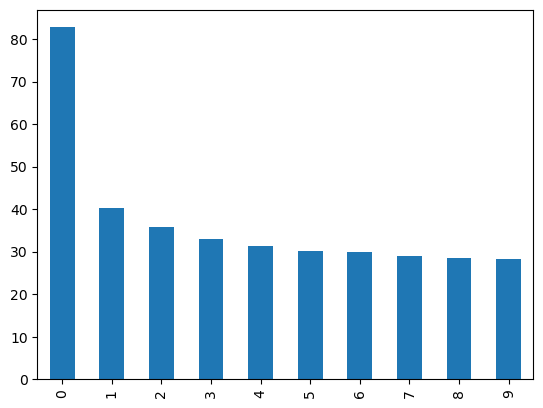

In [12]:
top10_games = df[df['Rank'] <= 10][['Name', 'Global_Sales']]

top10_games.plot(kind='bar', legend = None)
plt.show()

In [13]:
# Top Genres.

In [14]:
df.nlargest(5, 'Global_Sales')[['Genre','Global_Sales']]

,Genre,Global_Sales
0,Sports,82.74
1,Platform,40.24
2,Racing,35.82
3,Sports,33.00
4,Role-Playing,31.37


In [15]:
# Sum of sales according to Genre.

In [16]:
df.groupby('Genre')['Global_Sales'].sum().nlargest(5)

Genre
Action          1751.18
Sports          1330.93
Shooter         1037.37
Role-Playing     927.37
Platform         831.37
Name: Global_Sales, dtype: float64

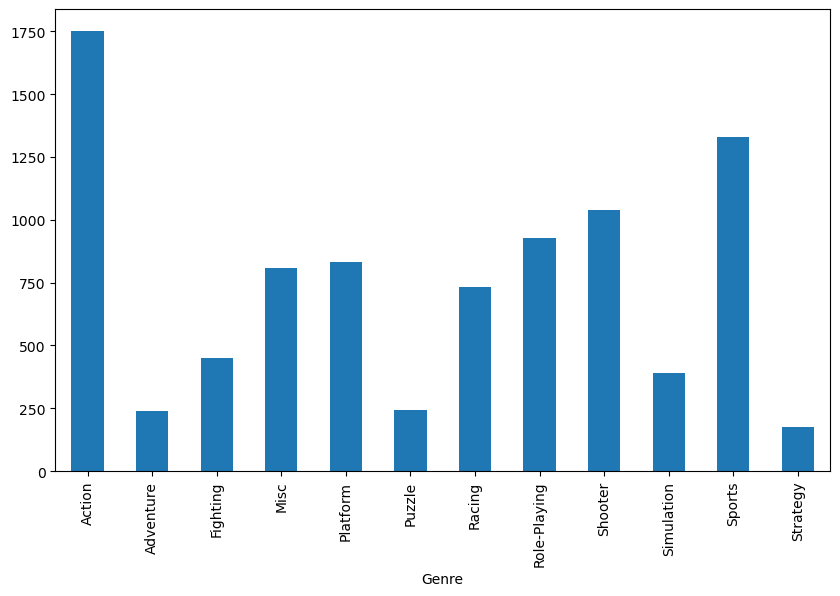

In [17]:
top_genre = df.groupby('Genre')['Global_Sales'].sum()
top_genre.plot(figsize=(10,6), kind = 'bar')
plt.show()

In [18]:
df.nlargest(5, 'Global_Sales')[['Platform','Global_Sales']]

,Platform,Global_Sales
0,Wii,82.74
1,NES,40.24
2,Wii,35.82
3,Wii,33.00
4,GB,31.37


In [19]:
# Sum of total sales per platform.

In [20]:
df.groupby('Platform')[ 'Global_Sales'].sum().nlargest(5)

Platform
PS2     1255.64
X360     979.96
PS3      957.84
Wii      926.71
DS       822.49
Name: Global_Sales, dtype: float64

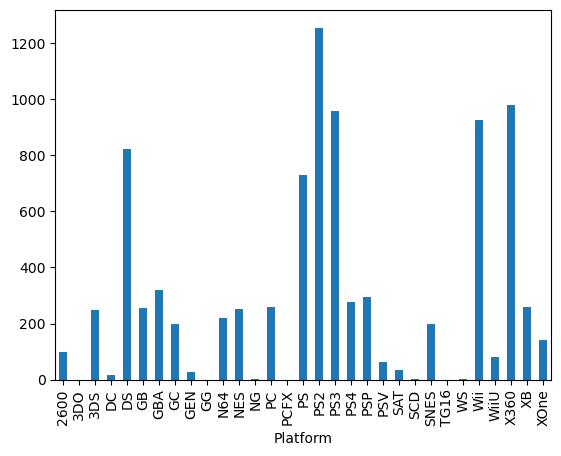

In [21]:
top_platform = df.groupby('Platform')['Global_Sales'].sum()
top_platform.plot(kind = 'bar')
plt.show()

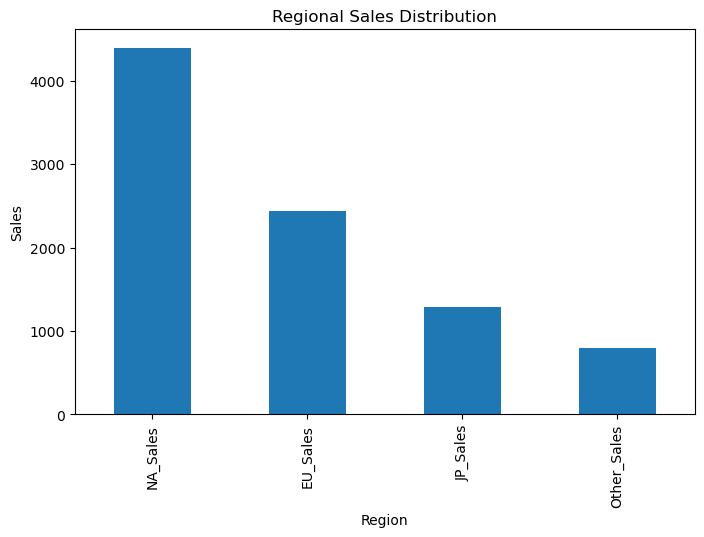

In [22]:
regional_sales = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

regional_sales.plot(kind='bar', figsize=(8, 5))

plt.xlabel('Region')
plt.ylabel('Sales')
plt.title('Regional Sales Distribution')
plt.show()

In [23]:
sales = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

percentage = (sales / sales.sum()) * 100

percentage

NA_Sales       49.271242
EU_Sales       27.301155
JP_Sales       14.480055
Other_Sales     8.947548
dtype: float64

### Visualization makes it much easier for us to understand and comprehend the qualities of our data.